In [1]:
# BAN6800 – BA-06: Exploratory Data Analysis
# CGSL Predictive Maintenance Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("EDA libraries loaded successfully.")

EDA libraries loaded successfully.


In [2]:
# Load the original UCI APS training dataset

train_url = "https://raw.githubusercontent.com/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/raw/aps_failure_training_set.csv"

df = pd.read_csv(
    train_url,
    skiprows=20,
    na_values="na"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Target distribution:")
print(df["class"].value_counts())

Dataset loaded successfully.
Shape: (60000, 171)
Target distribution:
class
neg    59000
pos     1000
Name: count, dtype: int64


In [3]:
# Create separate datasets for class-conditional EDA

df_neg = df[df["class"] == "neg"].copy()
df_pos = df[df["class"] == "pos"].copy()

print("Negative-class observations:", len(df_neg))
print("Positive-class observations:", len(df_pos))

Negative-class observations: 59000
Positive-class observations: 1000


In [4]:
# Calculate skewness for all numeric features

numeric_features = df.drop(columns=["class"])

skewness = numeric_features.skew().sort_values(ascending=False)

print("Top 15 most positively skewed features:")
display(skewness.head(15).to_frame("Skewness"))

print("\nTop 15 most negatively skewed features:")
display(skewness.tail(15).to_frame("Skewness"))

Top 15 most positively skewed features:


,Skewness
cs_009,243.531177
cf_000,212.459407
co_000,212.459406
ad_000,212.459406
dh_000,202.907014
az_009,163.609146
ay_009,159.066837
ag_000,153.387555
dj_000,150.507647
cs_007,140.732294



Top 15 most negatively skewed features:


,Skewness
bg_000,5.534854
ah_000,5.534549
bk_000,3.202804
bl_000,2.481207
bs_000,2.006974
ac_000,1.784845
bm_000,1.609165
bn_000,1.137405
bo_000,0.859990
ca_000,0.722104


## EDA Finding: Feature Skewness

Skewness analysis indicates substantial non-normality across several anonymized operational features. A number of variables exhibit very high positive skewness, including `cs_009`, `cf_000`, `co_000`, `ad_000`, and `dh_000`.

These results indicate that feature distributions are highly uneven, with some observations taking substantially larger values than most observations. This finding should be considered during feature engineering and model selection.

The returned lower-skewness group contains positive skewness values rather than negative values; therefore, no conclusion about negatively skewed features is made from this analysis.

Because the UCI feature names are anonymized, skewness is treated as a statistical property of the variables rather than evidence of a specific physical equipment condition.

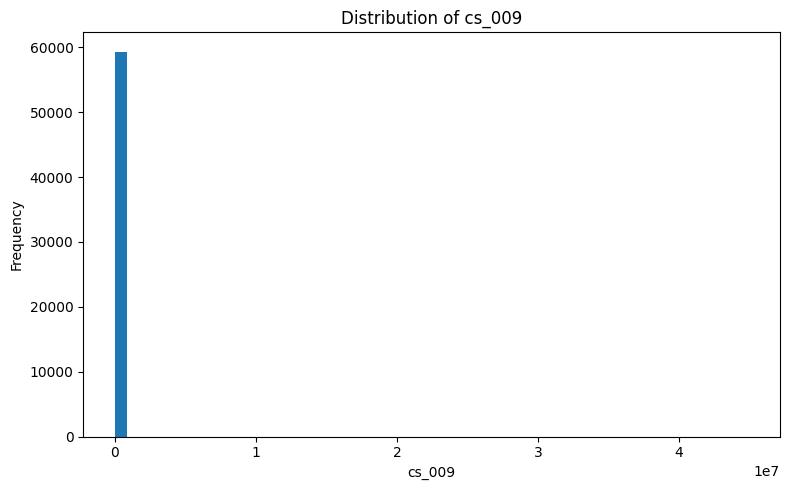

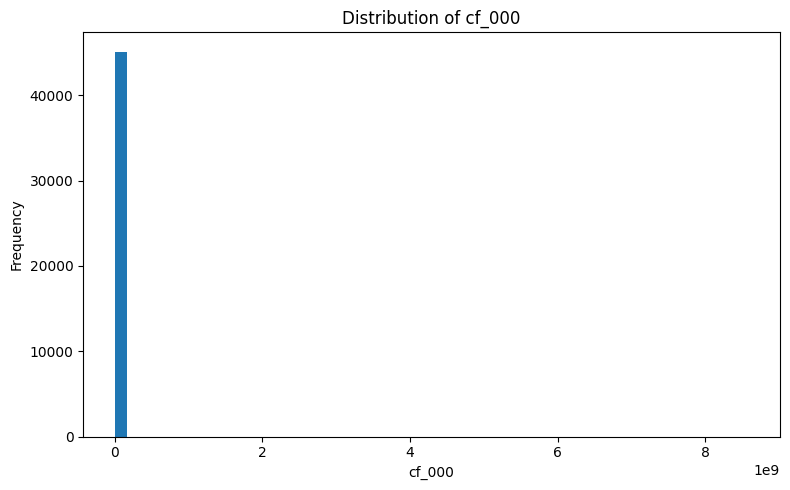

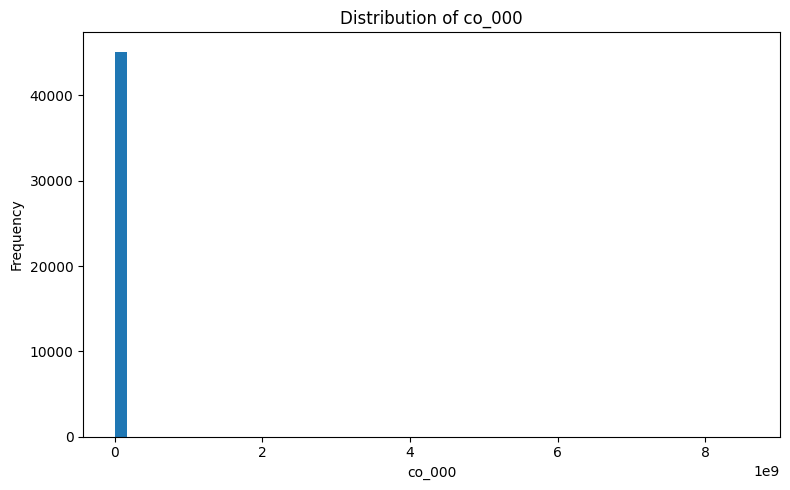

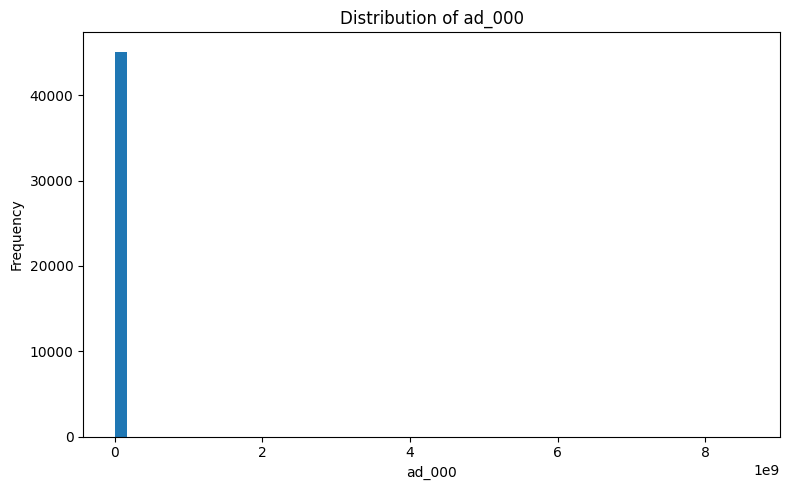

In [5]:
# Visualize distributions of highly skewed features

top_skewed_features = skewness.head(4).index.tolist()

for feature in top_skewed_features:
    plt.figure(figsize=(8, 5))
    plt.hist(df[feature].dropna(), bins=50)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

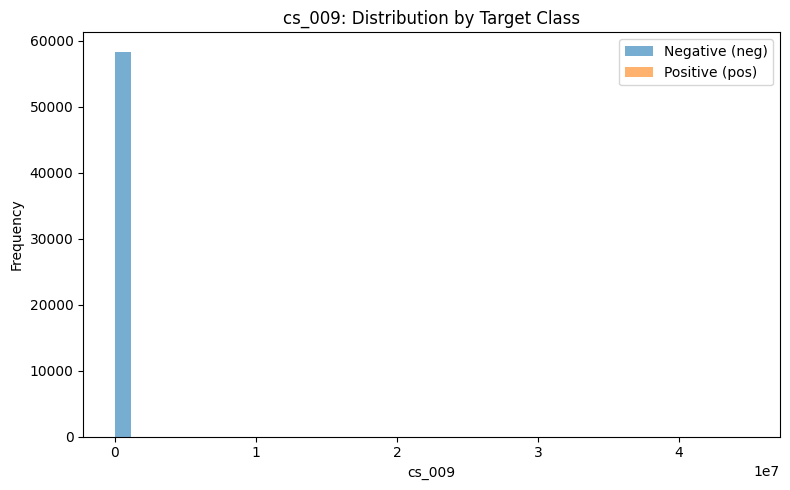

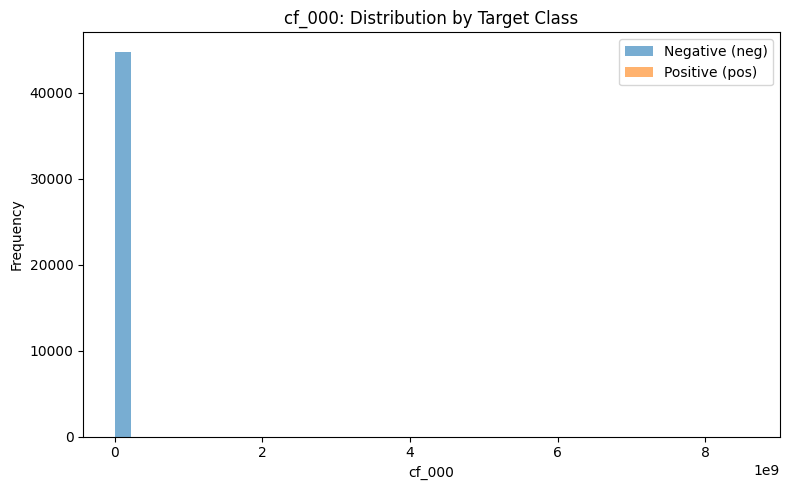

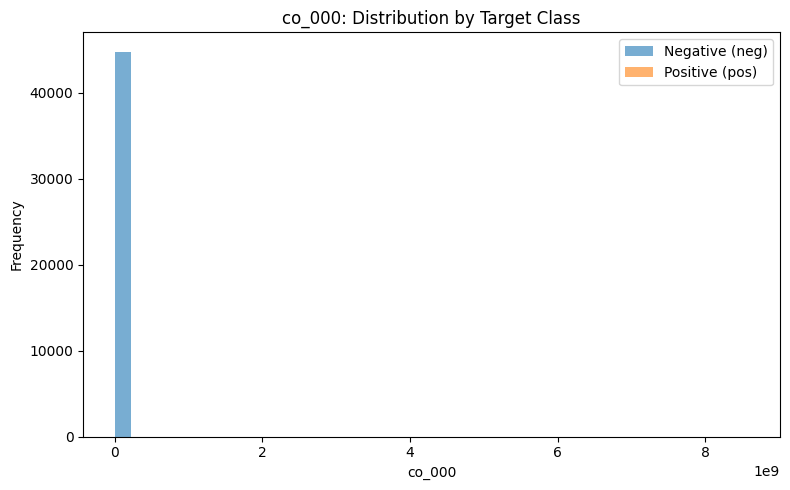

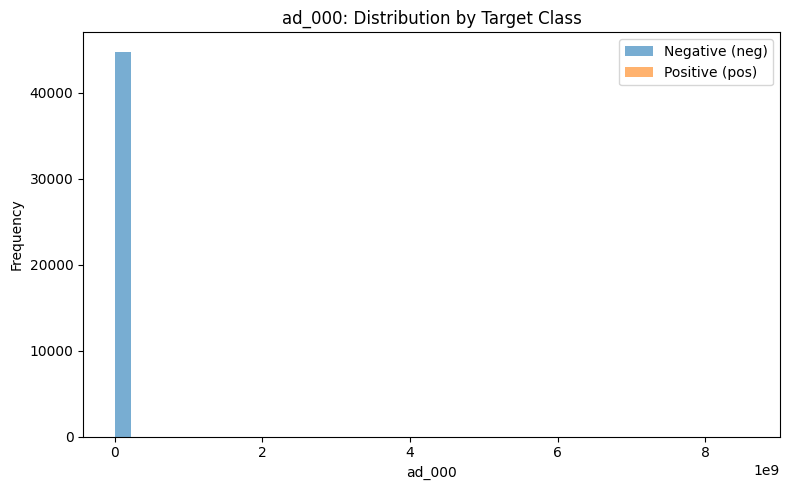

In [6]:
# Compare selected highly skewed features across target classes

comparison_features = ["cs_009", "cf_000", "co_000", "ad_000"]

for feature in comparison_features:
    plt.figure(figsize=(8, 5))

    plt.hist(
        df_neg[feature].dropna(),
        bins=40,
        alpha=0.6,
        label="Negative (neg)"
    )

    plt.hist(
        df_pos[feature].dropna(),
        bins=40,
        alpha=0.6,
        label="Positive (pos)"
    )

    plt.title(f"{feature}: Distribution by Target Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
# Compare median and mean values between negative and positive classes

comparison = pd.DataFrame({
    "Negative_Median": df_neg[comparison_features].median(),
    "Positive_Median": df_pos[comparison_features].median(),
    "Negative_Mean": df_neg[comparison_features].mean(),
    "Positive_Mean": df_pos[comparison_features].mean()
})

comparison["Median_Difference"] = (
    comparison["Positive_Median"] - comparison["Negative_Median"]
)

comparison["Median_Ratio"] = (
    comparison["Positive_Median"] /
    comparison["Negative_Median"].replace(0, np.nan)
)

display(comparison)

,Negative_Median,Positive_Median,Negative_Mean,Positive_Mean,Median_Difference,Median_Ratio
cs_009,0.0,0.0,792.317717,10.771084,0.0,NaN
cf_000,2.0,0.0,191718.355752,1429.526761,-2.0,0.000000
co_000,8.0,254.0,191993.428055,4080.264789,246.0,31.750000
ad_000,124.0,648.0,192113.744909,2262.214085,524.0,5.225806


## EDA Finding: Class-Conditional Feature Comparison

Class-conditional analysis was performed on four highly skewed anonymized operational features: `cs_009`, `cf_000`, `co_000`, and `ad_000`.

The analysis showed different patterns across the target classes. `co_000` had a negative-class median of 8 and a positive-class median of 254, while `ad_000` had a negative-class median of 124 and a positive-class median of 648. These represent the clearest median differences among the four selected features.

`cs_009` had a median of 0 in both classes, indicating that its median did not distinguish the groups, although its mean values differed substantially.

These results suggest that some anonymized operational variables may contain predictive information. However, the analysis does not establish causal relationships, and the physical meaning of the anonymized variables cannot be inferred from these results alone.

In [8]:
# Rank numeric features by absolute difference in class medians

numeric_features = df.drop(columns=["class"])

negative_medians = df_neg[numeric_features.columns].median()
positive_medians = df_pos[numeric_features.columns].median()

median_difference = (
    positive_medians - negative_medians
).abs().sort_values(ascending=False)

top_median_differences = median_difference.head(20).to_frame(
    "Absolute Median Difference"
)

display(top_median_differences)

,Absolute Median Difference
bb_000,45051162.00
bu_000,44845200.00
cq_000,44845200.00
bv_000,44845200.00
bx_000,38349367.00
eb_000,37029130.00
cc_000,36646640.00
ci_000,34252209.12
an_000,31241266.00
ao_000,26821524.00


## EDA Finding: Ranking Features by Class-Conditional Median Difference

A systematic comparison of class-conditional medians was performed across the numeric operational features.

The largest absolute median differences were observed for features including `bb_000`, `bu_000`, `cq_000`, `bv_000`, `bx_000`, `eb_000`, and `cc_000`.

These differences indicate that several anonymized operational variables have substantially different central tendencies between the negative and positive target classes.

However, absolute median differences are expressed in each feature's original measurement scale. Therefore, they should not be interpreted as a direct ranking of predictive importance. Further standardized analysis and model-based feature evaluation will be required.

Because the UCI feature names are anonymized, these statistical differences do not establish physical causes of APS failure.

In [9]:
# Calculate standardized mean differences between target classes

numeric_features = df.drop(columns=["class"])

neg_mean = df_neg[numeric_features.columns].mean()
pos_mean = df_pos[numeric_features.columns].mean()

neg_std = df_neg[numeric_features.columns].std()
pos_std = df_pos[numeric_features.columns].std()

pooled_std = np.sqrt((neg_std**2 + pos_std**2) / 2)

cohens_d = ((pos_mean - neg_mean) / pooled_std).replace(
    [np.inf, -np.inf], np.nan
).dropna()

cohens_d = cohens_d.abs().sort_values(ascending=False)

top_effect_sizes = cohens_d.head(20).to_frame(
    "Absolute Standardized Mean Difference"
)

display(top_effect_sizes)

,Absolute Standardized Mean Difference
ci_000,2.099201
ah_000,2.070545
bg_000,2.064619
bb_000,2.048320
bv_000,2.044255
bu_000,2.044254
cq_000,2.044254
an_000,2.009205
ao_000,1.955032
bt_000,1.935287


## EDA Finding: Standardized Class Separation

To reduce the influence of different measurement scales, standardized mean differences were calculated between the negative (`neg`) and positive (`pos`) target classes.

The largest absolute standardized mean differences were observed for `ci_000` (2.099), `ah_000` (2.071), `bg_000` (2.065), `bb_000` (2.048), `bv_000` (2.044), `bu_000` (2.044), and `cq_000` (2.044).

These results indicate substantial univariate distributional separation between the two target classes for several anonymized operational variables. However, this analysis does not establish causal relationships and should not be interpreted as final model feature importance. Multivariate modelling and validation will be required to determine the predictive contribution of these variables.

Because the UCI feature names are anonymized, no physical interpretation is assigned to the individual variables at this stage.

<Figure size 800x500 with 0 Axes>

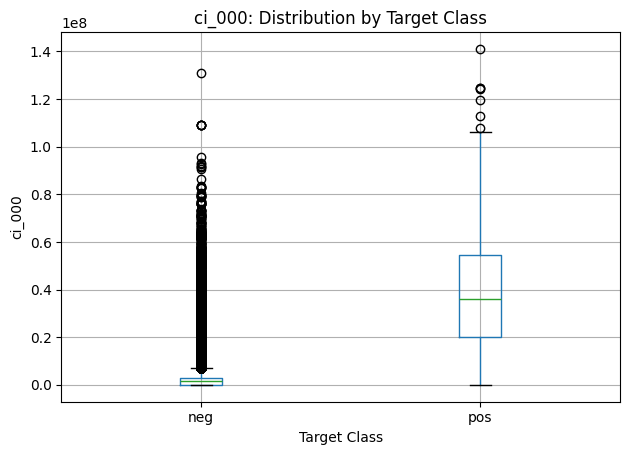

<Figure size 800x500 with 0 Axes>

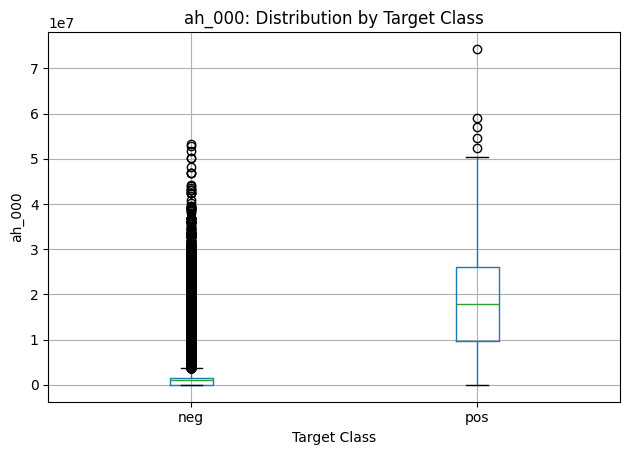

<Figure size 800x500 with 0 Axes>

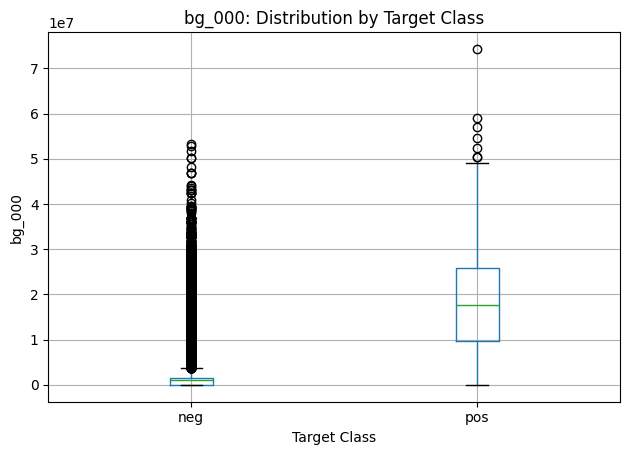

<Figure size 800x500 with 0 Axes>

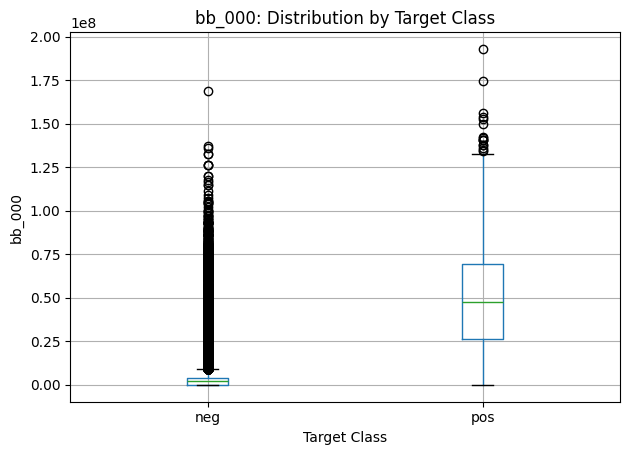

In [10]:
# Visualize class-conditional distributions for selected features

top_effect_features = [
    "ci_000",
    "ah_000",
    "bg_000",
    "bb_000"
]

for feature in top_effect_features:
    plt.figure(figsize=(8, 5))

    df.boxplot(
        column=feature,
        by="class"
    )

    plt.title(f"{feature}: Distribution by Target Class")
    plt.suptitle("")
    plt.xlabel("Target Class")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [11]:
# Calculate point-biserial-equivalent Pearson correlations
# between each numeric feature and the binary target

df_corr = df.copy()
df_corr["target_binary"] = (df_corr["class"] == "pos").astype(int)

numeric_features = df.drop(columns=["class"]).columns

feature_target_corr = (
    df_corr[numeric_features.tolist() + ["target_binary"]]
    .corr(numeric_only=True)["target_binary"]
    .drop("target_binary")
    .abs()
    .sort_values(ascending=False)
)

top_correlations = feature_target_corr.head(20).to_frame(
    "Absolute Correlation with Target"
)

display(top_correlations)

,Absolute Correlation with Target
ci_000,0.553308
bb_000,0.542744
bv_000,0.541598
bu_000,0.541598
cq_000,0.541598
bt_000,0.537452
aa_000,0.536978
aq_000,0.531135
bj_000,0.525249
ah_000,0.524591


## EDA Finding: Feature-Target Correlation

Absolute Pearson correlations were calculated between the numerical operational features and a binary representation of the target (`pos` = 1, `neg` = 0).

The strongest absolute correlations were observed for `ci_000` (0.553), `bb_000` (0.543), `bv_000` (0.542), `bu_000` (0.542), `cq_000` (0.542), `bt_000` (0.537), and `aa_000` (0.537).

`ci_000` showed the strongest linear association with the binary target among the features screened. Its high correlation is also consistent with the earlier standardized class-separation analysis.

These results are used for exploratory screening only. Correlation does not establish causation and does not represent final model feature importance. Multivariate modelling and cross-validation will be required to determine the predictive contribution of individual variables.

In [12]:
# Consolidate key BA-06 feature-screening results

eda_summary = pd.DataFrame({
    "Feature": top_correlations.index,
    "Absolute_Target_Correlation": top_correlations["Absolute Correlation with Target"].values
})

eda_summary["Absolute_Standardized_Mean_Difference"] = [
    cohens_d.get(feature, np.nan) for feature in eda_summary["Feature"]
]

eda_summary = eda_summary.sort_values(
    "Absolute_Target_Correlation",
    ascending=False
)

display(eda_summary.head(20))

# Save reproducible EDA screening output
eda_summary.to_csv("BA-06_feature_screening_summary.csv", index=False)

print("\nEDA feature-screening summary saved successfully.")

,Feature,Absolute_Target_Correlation,Absolute_Standardized_Mean_Difference
0,ci_000,0.553308,2.099201
1,bb_000,0.542744,2.048320
2,bv_000,0.541598,2.044255
3,bu_000,0.541598,2.044254
4,cq_000,0.541598,2.044254
5,bt_000,0.537452,1.935287
6,aa_000,0.536978,1.925151
7,aq_000,0.531135,1.717912
8,bj_000,0.525249,1.534773
9,ah_000,0.524591,2.070545



EDA feature-screening summary saved successfully.


## BA-06 EDA Conclusions

The exploratory analysis identified several important characteristics of the UCI APS dataset.

First, the numeric features exhibit substantial distributional variation and strong positive skewness in several variables. This confirms that the dataset contains highly uneven feature distributions and reinforces the need for appropriate preprocessing and model selection.

Second, class-conditional analysis identified measurable differences between the negative (`neg`) and positive (`pos`) classes for several anonymized operational features. In particular, `ci_000`, `bb_000`, `bv_000`, `bu_000`, and `cq_000` showed relatively strong standardized class separation and target correlation.

The feature-screening analysis provides candidate variables for subsequent feature engineering and modelling. However, these exploratory statistics do not establish causation and should not be treated as final feature importance. Multivariate model validation will determine which variables contribute meaningfully to predictive performance.

The anonymized nature of the UCI variables also limits physical interpretation. Therefore, findings are reported as statistical patterns rather than claims about specific mechanical or operational causes.